In [2]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from persiantools.jdatetime import JalaliDate
import jalali_pandas

In [3]:
df = pd.read_csv(r'../data/MCI.csv', encoding='utf-8')
df.head()

,<TICKER>,<DTYYYYMMDD>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>,<OPENINT>,<OPENINT>_1,<OPENINT>_2,<COl12>,<COl13>,<COl14>,<COl15>
0,همراه,20130820,42000,1000,42000,42001,2.295462e+10,2.295462e+10,69,1000,Iran Mobil Tele,شركت_ارتباطات_سيار_ايران,13920529,42200
1,همراه,20130821,42009,42001,42005,42142,6.929039e+09,6.929039e+09,214,42001,Iran Mobil Tele,شركت_ارتباطات_سيار_ايران,13920530,43400
2,همراه,20130824,43300,42142,42222,42191,4.724576e+09,4.724576e+09,168,42142,Iran Mobil Tele,شركت_ارتباطات_سيار_ايران,13920602,42222
3,همراه,20130825,42860,42191,42453,42213,2.869908e+09,2.869908e+09,94,42191,Iran Mobil Tele,شركت_ارتباطات_سيار_ايران,13920603,42550
4,همراه,20130826,42401,42213,42036,42214,6.768045e+09,6.768045e+09,121,42213,Iran Mobil Tele,شركت_ارتباطات_سيار_ايران,13920604,42050


In [4]:
df['Gregorian_Date'] = pd.to_datetime(df['<DTYYYYMMDD>'], format='%Y%m%d')
df["Jalali_Date"] = df["Gregorian_Date"].jalali.to_jalali()
df['year'] = df["Jalali_Date"].jalali.year
df['month'] = df["Jalali_Date"].jalali.month
df['day'] = df["Jalali_Date"].jalali.day
df['weekday'] = df["Jalali_Date"].jalali.weekday
df.drop(['<TICKER>','<OPENINT>','<COl12>','<COl13>','<DTYYYYMMDD>','<COl14>'],axis=1,inplace=True)

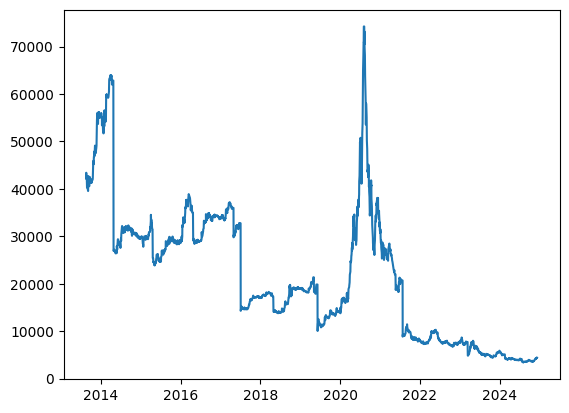

In [5]:
plt.plot(df['Gregorian_Date'],df['<COl15>'])

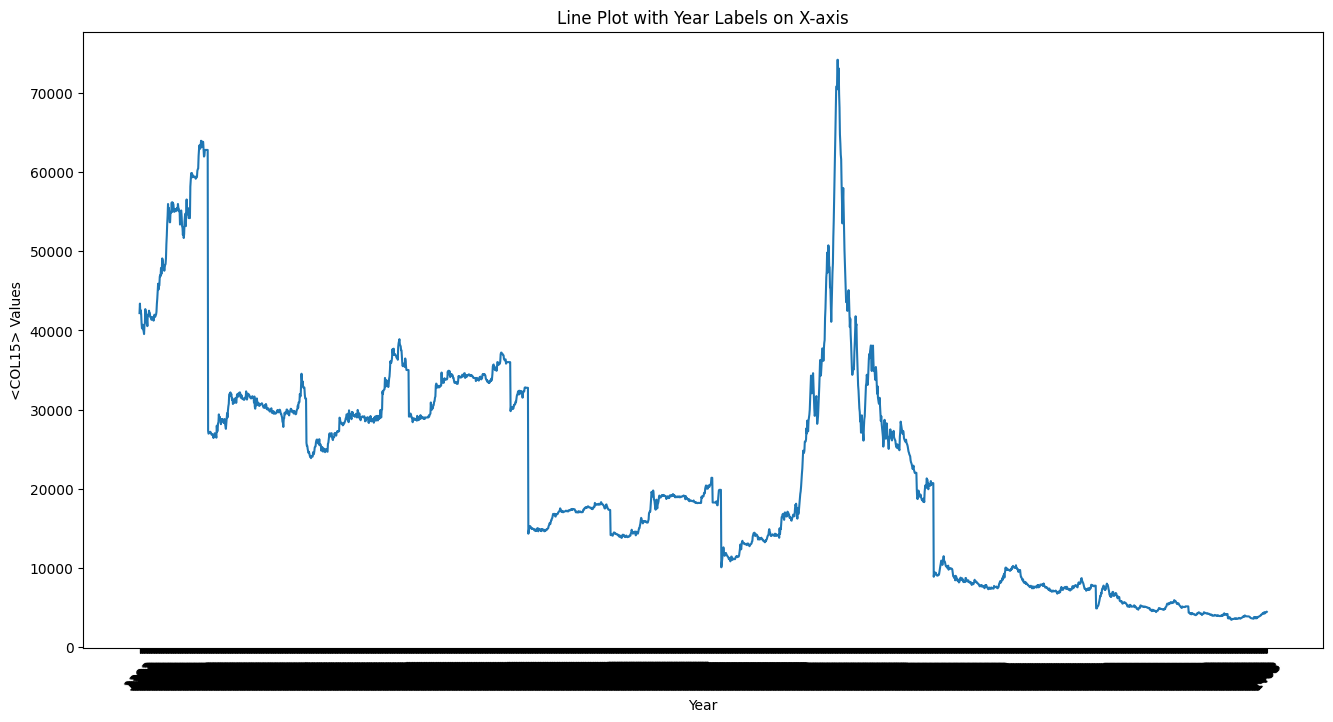

In [6]:
df['Jalali_Date_Str'] = df['Jalali_Date'].apply(lambda x: x.strftime('%Y-%m-%d'))
df['year1'] = df['Jalali_Date'].apply(lambda x: x.year)


plt.figure(figsize=(16, 8))  # Adjust plot size
plt.plot(df['Jalali_Date_Str'], df['<COl15>'])

# Replace x-axis ticks with 'year' labels
plt.xticks(ticks=range(len(df['Jalali_Date_Str'])), labels=df['year1'], rotation=45)

# Add labels and titles
plt.xlabel('Year')
plt.ylabel('<COL15> Values')  # Replace <COL15> with a descriptive label
plt.title('Line Plot with Year Labels on X-axis')


# Show plot
plt.show()